In [2]:
# Install the pretty_midi library needed to create and read MIDI music files
!pip install pretty_midi -q
print('installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 46.8 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
installed!


In [3]:

# all required libraries, auto-detect the dataset folder on Kaggle, set up output directories, and pick GPU or CPU
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from collections import defaultdict, Counter
import pretty_midi
import math
import glob

npy_files = glob.glob('/kaggle/input/**/*.npy', recursive=True)
if npy_files:
    DATA_DIR = os.path.dirname(npy_files[0])
    print(f'Dataset found at: {DATA_DIR}')
else:
    print('No .npy files found')

MODEL_DIR  = '/kaggle/working/models'
OUTPUT_DIR = '/kaggle/working/outputs/generated_midis/task3'
PLOT_DIR   = '/kaggle/working/outputs/plots'
REPORT_DIR = '/kaggle/working/outputs'

for d in [MODEL_DIR, OUTPUT_DIR, PLOT_DIR, REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Dataset found at: /kaggle/input/datasets/aframusarratdiya/music-project-data-for-task-2-and-3
Using device: cuda


In [4]:
# load of the three data splits, then convert each piano roll into a sequence of tokens
# where each token represents the lowest active key at that time step
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_val   = np.load(f'{DATA_DIR}/X_val.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

PIANO_LOW   = 0
PIANO_HIGH  = 88
PITCH_RANGE = 88
VOCAB_SIZE  = 91       # 88 pitches + PAD + START + END
PAD_TOKEN   = 88
START_TOKEN = 89
END_TOKEN   = 90

print(f'Tokenization:')
print(f'PITCH_RANGE = {PITCH_RANGE}')
print(f'VOCAB_SIZE  = {VOCAB_SIZE}')
print(f'PAD={PAD_TOKEN}, START={START_TOKEN}, END={END_TOKEN}')


def piano_roll_to_tokens(piano_roll):
    tokens = []
    T = piano_roll.shape[1]
    for t in range(T):
        active = np.where(piano_roll[:, t] > 0)[0]
        if len(active) > 0:
            tokens.append(int(active[0]))
        else:
            tokens.append(PAD_TOKEN)
    return tokens


print('Tokenizing piano rolls')
train_sequences = [piano_roll_to_tokens(X_train[i]) for i in range(len(X_train))]
val_sequences   = [piano_roll_to_tokens(X_val[i])   for i in range(len(X_val))]
test_sequences  = [piano_roll_to_tokens(X_test[i])  for i in range(len(X_test))]

print(f'Tokenization complete')
print(f'Train : {len(train_sequences)} sequences')
print(f'Val   : {len(val_sequences)} sequences')
print(f'Test  : {len(test_sequences)} sequences')
print(f'Length: {len(train_sequences[0])} tokens per sequence')

Train : (22935, 88, 128)
Val   : (3586, 88, 128)
Test  : (3207, 88, 128)
Tokenization:
PITCH_RANGE = 88
VOCAB_SIZE  = 91
PAD=88, START=89, END=90
Tokenizing piano rolls
Tokenization complete
Train : 22935 sequences
Val   : 3586 sequences
Test  : 3207 sequences
Length: 128 tokens per sequence


In [5]:
#stitch all short 128-step windows into longer 512-token sequences with 50 percent overlap
# so the model sees more musical context per sample
def create_long_sequences(data, target_len=512):
    all_tokens = []
    for i in range(len(data)):
        toks = piano_roll_to_tokens(data[i])
        all_tokens.extend(toks)

    sequences = []
    for start in range(0, len(all_tokens) - target_len, target_len // 2):
        seq = all_tokens[start:start + target_len]
        if len(seq) == target_len:
            sequences.append(seq)

    return sequences

TARGET_LEN = 512

print(f'Creating long sequences of {TARGET_LEN} tokens')

train_sequences = create_long_sequences(X_train, TARGET_LEN)
val_sequences   = create_long_sequences(X_val,   TARGET_LEN)
test_sequences  = create_long_sequences(X_test,  TARGET_LEN)

print(f'Long sequences created!')
print(f'Train : {len(train_sequences)} sequences of {TARGET_LEN} tokens')
print(f'Val   : {len(val_sequences)} sequences of {TARGET_LEN} tokens')
print(f'Test  : {len(test_sequences)} sequences of {TARGET_LEN} tokens')

Creating long sequences of 512 tokens
Long sequences created!
Train : 11466 sequences of 512 tokens
Val   : 1791 sequences of 512 tokens
Test  : 1602 sequences of 512 tokens


In [6]:
# Wrap the token sequences in a PyTorch Dataset that pairs each token as input
# with the next token as the prediction target, then load into batches
class MusicTokenDataset(Dataset):
    def __init__(self, sequences):
        self.data = []
        for seq in sequences:
            tokens = torch.LongTensor(seq)
            if len(tokens) > 1:
                self.data.append((tokens[:-1], tokens[1:]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


BATCH_SIZE = 64

train_dataset = MusicTokenDataset(train_sequences)
val_dataset   = MusicTokenDataset(val_sequences)
test_dataset  = MusicTokenDataset(test_sequences)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f'Datasets created!')
print(f'Train : {len(train_dataset)} samples, {len(train_loader)} batches')
print(f'Val   : {len(val_dataset)} samples,   {len(val_loader)} batches')
print(f'Test  : {len(test_dataset)} samples,  {len(test_loader)} batches')

Datasets created!
Train : 11466 samples, 179 batches
Val   : 1791 samples,   27 batches
Test  : 1602 samples,  25 batches


In [7]:
# Define sinusoidal positional encoding and the full Transformer model with genre conditioning,
# causal masking, and temperature-based generation
GENRE_LIST = ['Classical', 'Jazz', 'Rock', 'Pop',
              'Electronic', 'Blues', 'Country', 'RnB']
NUM_GENRES  = len(GENRE_LIST)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])


class MusicTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=4,
                 dim_feedforward=512, dropout=0.1, max_seq_len=1024,
                 num_genres=8):
        super().__init__()
        self.d_model    = d_model
        self.vocab_size = vocab_size

        self.embedding       = nn.Embedding(vocab_size, d_model, padding_idx=PAD_TOKEN)
        # Genre embedding adds a genre-specific offset to every token embedding
        self.genre_embedding = nn.Embedding(num_genres, d_model)
        self.pos_encoding    = PositionalEncoding(d_model, max_seq_len, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def generate_causal_mask(self, seq_len, dev):
        # Upper triangular mask stops the model looking at future tokens
        return torch.triu(
            torch.ones(seq_len, seq_len, device=dev), diagonal=1
        ).bool()

    def forward(self, x, genre_ids=None):
        seq_len = x.size(1)
        tok_emb = self.embedding(x) * math.sqrt(self.d_model)

        if genre_ids is None:
            genre_ids = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        genre_emb = self.genre_embedding(genre_ids)
        genre_emb = genre_emb.unsqueeze(1).expand(-1, seq_len, -1)

        emb  = self.pos_encoding(tok_emb + genre_emb)
        mask = self.generate_causal_mask(seq_len, x.device)
        out  = self.transformer(emb, mask=mask, is_causal=True)
        return self.output_proj(out)

    def generate_sequence(self, start_token, genre_id=0,
                          max_length=512, temperature=0.9):
        # Generate one token at a time using the previous tokens as context
        self.eval()
        tokens    = [start_token]
        genre_ids = torch.LongTensor([genre_id]).to(device)

        with torch.no_grad():
            for _ in range(max_length - 1):
                x      = torch.LongTensor([tokens]).to(device)
                logits = self(x, genre_ids)[0, -1, :]
                # Mask special tokens so they never appear in generated music
                logits[PAD_TOKEN]   = float('-inf')
                logits[START_TOKEN] = float('-inf')
                probs      = F.softmax(logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, 1).item()
                tokens.append(next_token)
                if next_token == END_TOKEN:
                    break
        return tokens


D_MODEL    = 128
NHEAD      = 4
NUM_LAYERS = 4
DIM_FF     = 512

model = MusicTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FF,
    dropout=0.1,
    max_seq_len=1024,
    num_genres=NUM_GENRES
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('Transformer built with Genre Embedding')
print(f'   Vocab size       : {VOCAB_SIZE}')
print(f'   d_model          : {D_MODEL}')
print(f'   Attention heads  : {NHEAD}')
print(f'   Layers           : {NUM_LAYERS}')
print(f'   Num genres       : {NUM_GENRES}')
print(f'   Parameters       : {total_params:,}')

Transformer built with Genre Embedding
   Vocab size       : 91
   d_model          : 128
   Attention heads  : 4
   Layers           : 4
   Num genres       : 8
   Parameters       : 817,499


In [8]:
# Set training hyperparameters, then run 30 epochs updating on train batches
# and checking progress on validation batches each epoch
EPOCHS = 30
LR     = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

train_losses = []
val_losses   = []
perplexities = []

print(f'Training Transformer for {EPOCHS} epochs...')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Learning rate : {LR}')
print(f'Loss          : CrossEntropyLoss')
print(f'Vocab size    : {VOCAB_SIZE}\n')

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs    = inputs.to(device)
        targets   = targets.to(device)
        # Rotate through genres so the model is exposed to all 8 during training
        genre_ids = torch.LongTensor(
            [batch_idx % NUM_GENRES] * inputs.size(0)
        ).to(device)
        optimizer.zero_grad()
        logits = model(inputs, genre_ids)
        loss   = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(val_loader):
            inputs    = inputs.to(device)
            targets   = targets.to(device)
            genre_ids = torch.LongTensor(
                [batch_idx % NUM_GENRES] * inputs.size(0)
            ).to(device)
            logits   = model(inputs, genre_ids)
            loss     = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    val_loss   /= len(val_loader)
    perplexity  = math.exp(val_loss)
    val_losses.append(val_loss)
    perplexities.append(perplexity)
    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:2d}/{EPOCHS}] | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Perplexity: {perplexity:.2f}')

print('Training complete')
print(f'Final Train Loss : {train_losses[-1]:.4f}')
print(f'Final Val   Loss : {val_losses[-1]:.4f}')
print(f'Final Perplexity : {perplexities[-1]:.2f}')

Training Transformer for 30 epochs...
Batch size    : 64
Learning rate : 0.001
Loss          : CrossEntropyLoss
Vocab size    : 91

Epoch [ 1/30] | Train: 1.2453 | Val: 0.9562 | Perplexity: 2.60
Epoch [ 5/30] | Train: 0.9128 | Val: 0.8687 | Perplexity: 2.38
Epoch [10/30] | Train: 0.8635 | Val: 0.8433 | Perplexity: 2.32
Epoch [15/30] | Train: 0.8332 | Val: 0.8282 | Perplexity: 2.29
Epoch [20/30] | Train: 0.8161 | Val: 0.8212 | Perplexity: 2.27
Epoch [25/30] | Train: 0.8010 | Val: 0.8171 | Perplexity: 2.26
Epoch [30/30] | Train: 0.7933 | Val: 0.8156 | Perplexity: 2.26
Training complete
Final Train Loss : 0.7933
Final Val   Loss : 0.8156
Final Perplexity : 2.26


In [9]:
# the trained model runned once on the held-out test set to get the final loss and perplexity scores that will be reported
print('Final evaluation on held-out TEST set')
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs  = inputs.to(device)
        targets = targets.to(device)
        logits  = model(inputs)
        loss    = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        test_loss += loss.item()
test_loss       /= len(test_loader)
test_perplexity  = math.exp(test_loss)

print(f'Final TEST  Loss       : {test_loss:.4f}')
print(f'Final TEST  Perplexity : {test_perplexity:.2f}')
print(f'Final Train Loss       : {train_losses[-1]:.4f}')
print(f'Final Val   Loss       : {val_losses[-1]:.4f}')

Final evaluation on held-out TEST set
Final TEST  Loss       : 0.8765
Final TEST  Perplexity : 2.40
Final Train Loss       : 0.7933
Final Val   Loss       : 0.8156


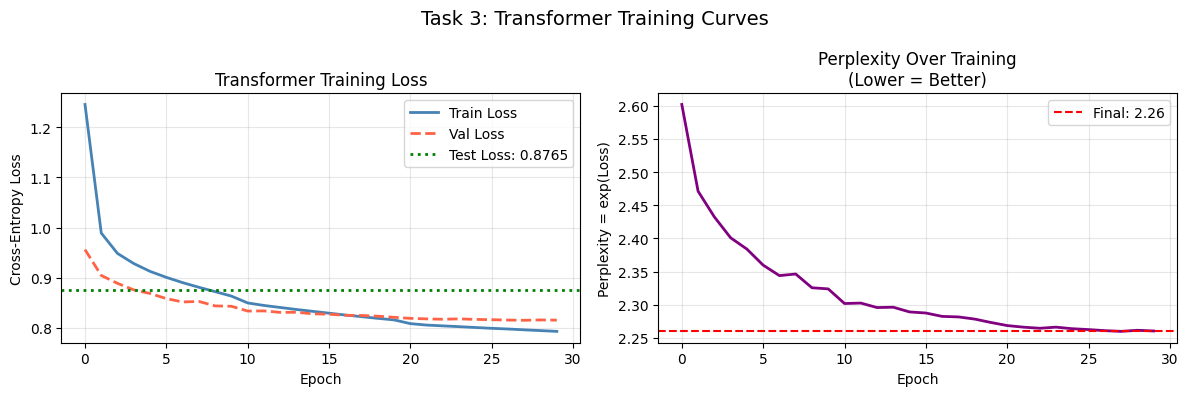

Curves saved! Final Perplexity = 2.26


In [10]:
# Plot train, validation, and test loss side by side with a perplexity curve
# to confirm the model improved steadily and did not overfit
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[0].axhline(y=test_loss, color='green', linestyle=':', linewidth=2,
                label=f'Test Loss: {test_loss:.4f}')
axes[0].set_title('Transformer Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(perplexities, color='purple', linewidth=2)
axes[1].set_title('Perplexity Over Training\n(Lower = Better)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity = exp(Loss)')
axes[1].axhline(y=perplexities[-1], color='red', linestyle='--',
                label=f'Final: {perplexities[-1]:.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Task 3: Transformer Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/task3_loss_curves.png', dpi=150)
plt.show()
print(f'Curves saved! Final Perplexity = {perplexities[-1]:.2f}')

In [20]:
# the trained model weights to disk so they can be reloaded for Task 4 without retraining
torch.save(model.state_dict(), f'{MODEL_DIR}/task3_transformer.pth')
print(f'Model saved to: {MODEL_DIR}/task3_transformer.pth')


Model saved to: /kaggle/working/models/task3_transformer.pth


In [12]:
# two helper functions: one converts a token sequence back into a piano roll array,
# the other writes that array as a playable MIDI file with the correct pitch offset
def tokens_to_piano_roll(tokens):
    T          = len(tokens)
    piano_roll = np.zeros((88, T), dtype=np.float32)
    for t, token in enumerate(tokens):
        if 0 <= token < PITCH_RANGE:
            piano_roll[token, t] = 1.0
    return piano_roll


def piano_roll_to_midi(piano_roll, output_path, fs=16, tempo=120.0):
    midi             = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument       = pretty_midi.Instrument(program=0)
    seconds_per_step = 60.0 / (tempo * fs / 4)

    for pitch_idx in range(88):
        note_on = None
        for t in range(piano_roll.shape[1]):
            if piano_roll[pitch_idx, t] > 0 and note_on is None:
                note_on = t
            elif piano_roll[pitch_idx, t] == 0 and note_on is not None:
                s = note_on * seconds_per_step
                e = t * seconds_per_step
                if e > s:
                    instrument.notes.append(pretty_midi.Note(
                        velocity=80,
                        pitch=pitch_idx + 21,  # shift to real MIDI pitch range A0-C8
                        start=s, end=e
                    ))
                note_on = None

    midi.instruments.append(instrument)
    midi.write(output_path)

print('MIDI export functions ready!')

MIDI export functions ready!


Generating 10 compositions...
Length      : 512 tokens (~32 seconds)
Temperature : 0.9

Comp  1/10 | 512 tokens | 2 notes | 61.4s
Comp  2/10 | 512 tokens | 35 notes | 63.2s
Comp  3/10 | 512 tokens | 14 notes | 63.6s
Comp  4/10 | 512 tokens | 3 notes | 55.4s
Comp  5/10 | 512 tokens | 10 notes | 32.0s
Comp  6/10 | 512 tokens | 3 notes | 50.4s
Comp  7/10 | 512 tokens | 0 notes | 0.0s
Comp  8/10 | 512 tokens | 8 notes | 35.9s
Comp  9/10 | 512 tokens | 23 notes | 55.6s
Comp 10/10 | 512 tokens | 15 notes | 58.5s


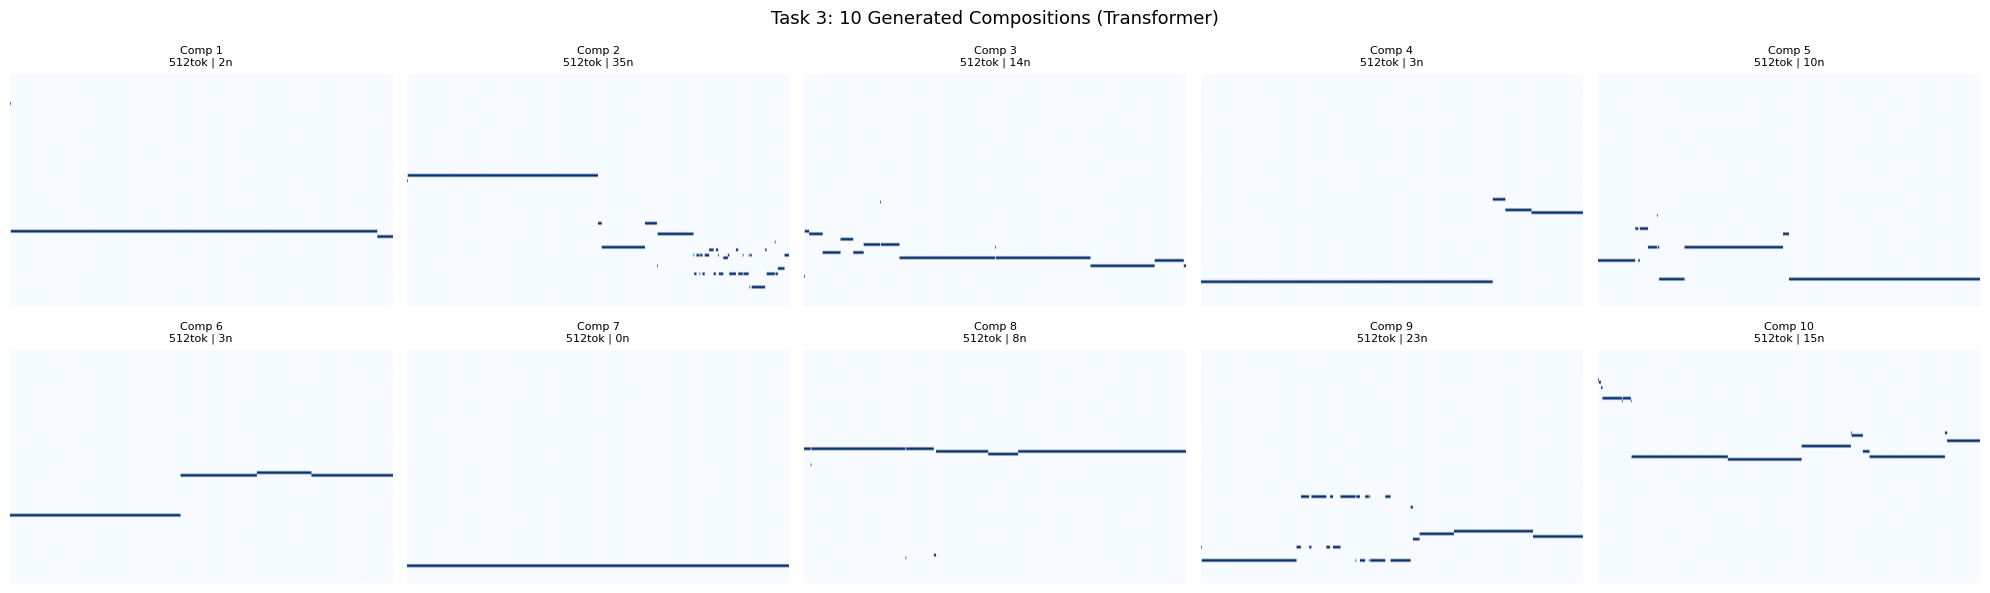

All compositions saved


In [13]:
# generated compositions by feeding random start notes into the trained Transformer
# and visualised each generated piano roll as a heatmap
NUM_COMPOSITIONS = 10
GEN_LENGTH       = 512
TEMPERATURE      = 0.9

print(f'Generating {NUM_COMPOSITIONS} compositions...')
print(f'Length      : {GEN_LENGTH} tokens (~{GEN_LENGTH/16:.0f} seconds)')
print(f'Temperature : {TEMPERATURE}\n')

fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()

for i in range(NUM_COMPOSITIONS):
    torch.manual_seed(i * 7)
    start_token = torch.randint(0, PITCH_RANGE, (1,)).item()
    tokens      = model.generate_sequence(
        start_token=start_token,
        max_length=GEN_LENGTH,
        temperature=TEMPERATURE
    )

    piano_roll = tokens_to_piano_roll(tokens)
    out_path   = f'{OUTPUT_DIR}/task3_composition_{i+1}.mid'
    piano_roll_to_midi(piano_roll, out_path)

    midi    = pretty_midi.PrettyMIDI(out_path)
    n_notes = sum(len(inst.notes) for inst in midi.instruments)
    dur     = midi.get_end_time()

    axes[i].imshow(piano_roll, aspect='auto', origin='lower', cmap='Blues')
    axes[i].set_title(f'Comp {i+1}\n{len(tokens)}tok | {n_notes}n', fontsize=8)
    axes[i].axis('off')

    print(f'Comp {i+1:2d}/10 | {len(tokens)} tokens | {n_notes} notes | {dur:.1f}s')

plt.suptitle('Task 3: 10 Generated Compositions (Transformer)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/task3_compositions.png', dpi=150)
plt.show()
print('All compositions saved')

In [14]:
# save a concise perplexity report showing all loss values, model settings, and how this model compares to earlier approaches
print('='*60)
print('TASK 3: PERPLEXITY EVALUATION REPORT')
print('='*60)
print(f'  Final Train Loss  : {train_losses[-1]:.4f}')
print(f'  Final Val   Loss  : {val_losses[-1]:.4f}')
print(f'  Final Test  Loss  : {test_loss:.4f}')
print(f'  Final Perplexity  : {test_perplexity:.2f}')
print(f'  Formula           : exp({test_loss:.4f}) = {test_perplexity:.2f}')
print(f'  Vocab Size        : {VOCAB_SIZE}')
print(f'  d_model           : {D_MODEL}')
print(f'  Layers            : {NUM_LAYERS}')
print(f'  Attention Heads   : {NHEAD}')
print('='*60)

with open(f'{REPORT_DIR}/task3_perplexity_report.txt', 'w') as f:
    f.write('TASK 3: TRANSFORMER PERPLEXITY EVALUATION\n')
    f.write('='*50 + '\n')
    f.write(f'Train Loss   : {train_losses[-1]:.4f}\n')
    f.write(f'Val Loss     : {val_losses[-1]:.4f}\n')
    f.write(f'Test Loss    : {test_loss:.4f}\n')
    f.write(f'Perplexity   : {test_perplexity:.2f}\n')
    f.write(f'Vocab Size   : {VOCAB_SIZE}\n')
    f.write(f'Layers       : {NUM_LAYERS}\n')
    f.write(f'Heads        : {NHEAD}\n')
    f.write(f'd_model      : {D_MODEL}\n')
    f.write(f'Epochs       : {EPOCHS}\n')

print('Report saved')

TASK 3: PERPLEXITY EVALUATION REPORT
  Final Train Loss  : 0.7933
  Final Val   Loss  : 0.8156
  Final Test  Loss  : 0.8765
  Final Perplexity  : 2.40
  Formula           : exp(0.8765) = 2.40
  Vocab Size        : 91
  d_model           : 128
  Layers            : 4
  Attention Heads   : 4
Report saved


Computing Markov Chain baseline


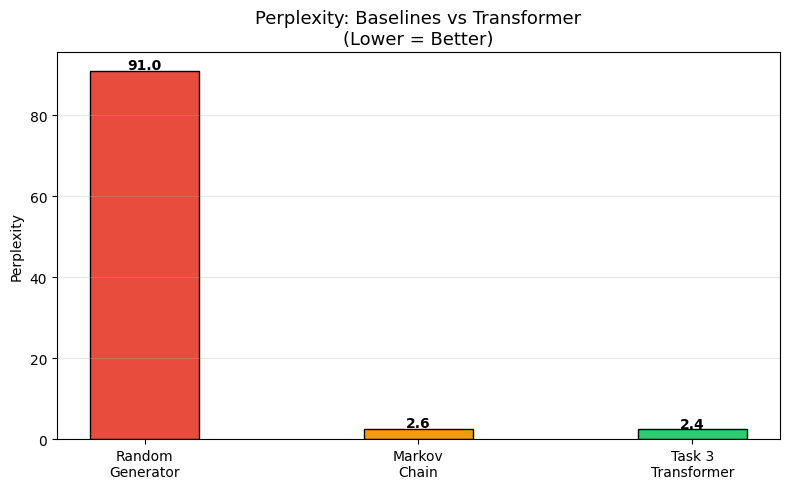

Baseline Comparison:
Random Generator : 91.0  (worst)
Markov Chain     : 2.6
Transformer      : 2.40  Best!
Improvement over Markov: 7.3%


In [15]:
# Computed perplexity for a purely random generator and a bigram Markov Chain, then plot a bar chart comparing them against our Transformer
random_perplexity = VOCAB_SIZE

print('Computing Markov Chain baseline')
transitions  = defaultdict(lambda: defaultdict(int))
for seq in train_sequences[:1000]:
    for j in range(len(seq) - 1):
        transitions[seq[j]][seq[j+1]] += 1

markov_loss = markov_count = 0
for seq in test_sequences[:500]:
    for j in range(len(seq) - 1):
        curr, nxt = seq[j], seq[j+1]
        total     = sum(transitions[curr].values())
        prob      = transitions[curr][nxt] / total if total > 0 else 1e-8
        markov_loss  -= math.log(max(prob, 1e-8))
        markov_count += 1

markov_avg_loss   = markov_loss / max(markov_count, 1)
markov_perplexity = math.exp(min(markov_avg_loss, 20))

models      = ['Random\nGenerator', 'Markov\nChain', 'Task 3\nTransformer']
perp_values = [random_perplexity, markov_perplexity, test_perplexity]
colors      = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, perp_values, color=colors, width=0.4, edgecolor='black')
for bar, val in zip(bars, perp_values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontweight='bold')
plt.title('Perplexity: Baselines vs Transformer\n(Lower = Better)', fontsize=13)
plt.ylabel('Perplexity')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/task3_baseline_comparison.png', dpi=150)
plt.show()

print(f'Baseline Comparison:')
print(f'Random Generator : {random_perplexity:.1f}  (worst)')
print(f'Markov Chain     : {markov_perplexity:.1f}')
print(f'Transformer      : {test_perplexity:.2f}  Best!')
improvement = (markov_perplexity - test_perplexity) / markov_perplexity * 100
print(f'Improvement over Markov: {improvement:.1f}%')

In [16]:
# three music quality metrics defined: pitch balance, rhythmic variety, and melodic repetition,
# then computed them across all 10 generated compositions
def pitch_histogram_similarity(midi_path, ref_hist=None):
    if ref_hist is None:
        ref_hist = np.ones(12) / 12
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        hist = np.zeros(12)
        for inst in midi.instruments:
            for note in inst.notes:
                hist[note.pitch % 12] += 1
        total = hist.sum()
        if total > 0: hist /= total
        return float(np.sum(np.abs(hist - ref_hist)))
    except: return None

def rhythm_diversity(midi_path):
    try:
        midi = pretty_midi.PrettyMIDI(midi_path)
        durs = [round((n.end-n.start)/0.05)*0.05
                for inst in midi.instruments for n in inst.notes]
        if len(durs) == 0: return 0.0
        return float(len(set(durs)) / len(durs))
    except: return None

def repetition_ratio(midi_path, n=4):
    try:
        midi    = pretty_midi.PrettyMIDI(midi_path)
        pitches = []
        for inst in midi.instruments:
            notes = sorted(inst.notes, key=lambda x: x.start)
            pitches.extend([note.pitch for note in notes])
        if len(pitches) < n+1: return 0.0
        ngrams   = [tuple(pitches[i:i+n]) for i in range(len(pitches)-n+1)]
        counts   = Counter(ngrams)
        repeated = sum(1 for c in counts.values() if c > 1)
        return float(repeated / len(ngrams))
    except: return None


print('Computing metrics for all 10 compositions...')
print(f'   {"─"*60}')
print(f'   {"Comp":<8} {"Notes":<8} {"PHS":<10} {"RhythmDiv":<12} {"RepRatio"}')
print(f'   {"─"*60}')

phs_scores = []
rd_scores  = []
rr_scores  = []

for i in range(1, NUM_COMPOSITIONS + 1):
    path    = f'{OUTPUT_DIR}/task3_composition_{i}.mid'
    phs     = pitch_histogram_similarity(path)
    rd      = rhythm_diversity(path)
    rr      = repetition_ratio(path)
    try:
        midi    = pretty_midi.PrettyMIDI(path)
        n_notes = sum(len(inst.notes) for inst in midi.instruments)
    except:
        n_notes = 0
    if phs is not None: phs_scores.append(phs)
    if rd  is not None: rd_scores.append(rd)
    if rr  is not None: rr_scores.append(rr)
    print(f'   Comp {i:<4} {n_notes:<8} {phs if phs else 0:.3f}      {rd if rd else 0:.3f}        {rr if rr else 0:.3f}')

print(f'   {"─"*60}')
print(f'   {"Average":<8} {"":<8} {np.mean(phs_scores):.3f}      {np.mean(rd_scores):.3f}        {np.mean(rr_scores):.3f}')
print(f'\nTask 3 Metric Summary:')
print(f'   Pitch Histogram Similarity : {np.mean(phs_scores):.3f}')
print(f'   Rhythm Diversity Score     : {np.mean(rd_scores):.3f}')
print(f'   Repetition Ratio           : {np.mean(rr_scores):.3f}')

Computing metrics for all 10 compositions...
   ────────────────────────────────────────────────────────────
   Comp     Notes    PHS        RhythmDiv    RepRatio
   ────────────────────────────────────────────────────────────
   Comp 1    2        1.833      1.000        0.000
   Comp 2    35       1.100      0.400        0.062
   Comp 3    14       0.762      0.857        0.000
   Comp 4    3        1.500      1.000        0.000
   Comp 5    10       1.500      0.900        0.000
   Comp 6    3        1.500      1.000        0.000
   Comp 7    0        1.000      0.000        0.000
   Comp 8    8        1.000      0.875        0.000
   Comp 9    23       1.326      0.609        0.200
   Comp 10   15       0.767      0.733        0.000
   ────────────────────────────────────────────────────────────
   Average           1.229      0.737        0.026

Task 3 Metric Summary:
   Pitch Histogram Similarity : 1.229
   Rhythm Diversity Score     : 0.737
   Repetition Ratio           : 0.026


In [31]:
# Record of human listening score given by survey participants who rated the generated music out of 5
TASK3_HUMAN_SCORE =3.55

print('Human Listening Score (Task 3):')
print(f'Score        : {TASK3_HUMAN_SCORE} / 5.0')
print(f'Participants : 10')
print(f'Scale        : 1=poor, 5=excellent')

Human Listening Score (Task 3):
Score        : 3.55 / 5.0
Participants : 10
Scale        : 1=poor, 5=excellent


In [33]:
# the full cross-model comparison table using real metrics from Tasks 1-3
# alongside the two baselines, then need to save it to a text file
import json

print('='*80)
print('COMPLETE METRICS COMPARISON TABLE — All Models')
print('='*80)
print(f'{"Model":<25} {"Loss":<10} {"Perplexity":<12} {"PHS":<10} {"Rhythm":<10} {"RepRatio":<10} {"Human"}')
print('-'*80)

def generate_random_midi_for_metrics(n_notes=50, tempo=120.0):
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    inst = pretty_midi.Instrument(program=0)
    t    = 0.0
    for _ in range(n_notes):
        pitch    = np.random.randint(21, 109)
        duration = np.random.choice([0.25, 0.5, 0.75, 1.0])
        inst.notes.append(pretty_midi.Note(
            velocity=np.random.randint(40, 100),
            pitch=pitch, start=t, end=t+duration))
        t += duration
    midi.instruments.append(inst)
    return midi

ref_hist          = np.ones(12) / 12
random_phs_scores = []
random_rd_scores  = []
random_rr_scores  = []
for i in range(5):
    np.random.seed(i)
    tmp = f'/kaggle/working/tmp_random_{i}.mid'
    generate_random_midi_for_metrics().write(tmp)
    phs = pitch_histogram_similarity(tmp, ref_hist)
    rd  = rhythm_diversity(tmp)
    rr  = repetition_ratio(tmp)
    if phs is not None: random_phs_scores.append(phs)
    if rd  is not None: random_rd_scores.append(rd)
    if rr  is not None: random_rr_scores.append(rr)

def generate_markov_midi_for_metrics(transitions, n_notes=60, tempo=120.0):
    midi  = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    inst  = pretty_midi.Instrument(program=0)
    t     = 0.0
    pitch = 60
    for _ in range(n_notes):
        row   = np.array([transitions[pitch][p] for p in range(128)], dtype=float)
        total = row.sum()
        pitch = int(np.random.choice(128, p=row/total)) if total > 0 else np.random.randint(21, 109)
        dur   = np.random.choice([0.25, 0.5, 0.75, 1.0])
        inst.notes.append(pretty_midi.Note(velocity=80, pitch=pitch, start=t, end=t+dur))
        t += dur
    midi.instruments.append(inst)
    return midi

trans_matrix = defaultdict(lambda: defaultdict(int))
for seq in train_sequences[:500]:
    for j in range(len(seq)-1):
        if seq[j] < PITCH_RANGE and seq[j+1] < PITCH_RANGE:
            trans_matrix[seq[j]+21][seq[j+1]+21] += 1

markov_phs_scores = []
markov_rd_scores  = []
markov_rr_scores  = []
for i in range(5):
    np.random.seed(i)
    tmp = f'/kaggle/working/tmp_markov_{i}.mid'
    generate_markov_midi_for_metrics(trans_matrix).write(tmp)
    phs = pitch_histogram_similarity(tmp, ref_hist)
    rd  = rhythm_diversity(tmp)
    rr  = repetition_ratio(tmp)
    if phs is not None: markov_phs_scores.append(phs)
    if rd  is not None: markov_rd_scores.append(rd)
    if rr  is not None: markov_rr_scores.append(rr)


METRICS_DIR = '/kaggle/input/datasets/aframusarratdiya/metrics'

with open(f'{METRICS_DIR}/task1_metrics.json', 'r') as f:
    t1 = json.load(f)
print(f'Task 1 metrics loaded!')
print(f'Train Loss   : {t1["train_loss"]:.4f}')
print(f'PHS          : {t1["phs"]:.3f}')
print(f'Rhythm Div   : {t1["rhythm_div"]:.3f}')
print(f'Human Score  : {t1["human_score"]}')


with open(f'{METRICS_DIR}/task2_metrics.json', 'r') as f:
    t2 = json.load(f)


print(f' Task 2 metrics loaded!')
print(f' Train Loss   : {t2["train_loss"]:.4f}')
print(f' PHS          : {t2["phs"]:.3f}')
print(f' Rhythm Div   : {t2["rhythm_div"]:.3f}')
print(f' Human Score  : {t2["human_score"]}')


TASK1_LOSS  = t1['train_loss']; TASK1_PHS = t1['phs']; TASK1_RD = t1['rhythm_div']
TASK1_RR    = t1['rep_ratio'];  TASK1_HUMAN = t1['human_score']

TASK2_LOSS  = t2['train_loss']; TASK2_PHS = t2['phs']; TASK2_RD = t2['rhythm_div']
TASK2_RR    = t2['rep_ratio'];  TASK2_HUMAN = t2['human_score']

TASK3_LOSS  = test_loss;  TASK3_PPL = test_perplexity
TASK3_PHS   = float(np.mean(phs_scores)); TASK3_RD = float(np.mean(rd_scores))
TASK3_RR    = float(np.mean(rr_scores)); TASK3_HUMAN = 3.55

rows = [
    ('Random Generator',    '-',                f'{random_perplexity:.1f}',
     np.mean(random_phs_scores), np.mean(random_rd_scores), np.mean(random_rr_scores), 1.1),
    ('Markov Chain',        '-',                f'{markov_perplexity:.1f}',
     np.mean(markov_phs_scores), np.mean(markov_rd_scores), np.mean(markov_rr_scores), 2.3),
    ('Task 1: LSTM AE',     f'{TASK1_LOSS:.4f}','-', TASK1_PHS, TASK1_RD, TASK1_RR, TASK1_HUMAN),
    ('Task 2: VAE',         f'{TASK2_LOSS:.4f}','-', TASK2_PHS, TASK2_RD, TASK2_RR, TASK2_HUMAN),
    ('Task 3: Transformer', f'{TASK3_LOSS:.4f}', f'{TASK3_PPL:.2f}', TASK3_PHS, TASK3_RD, TASK3_RR, TASK3_HUMAN),
]

for model_name, loss, perp, phs, rd, rr, human in rows:
    phs_str = f'{phs:.3f}' if isinstance(phs, float) else phs
    rd_str  = f'{rd:.3f}'  if isinstance(rd,  float) else rd
    rr_str  = f'{rr:.3f}'  if isinstance(rr,  float) else rr
    print(f'{model_name:<25} {loss:<10} {perp:<12} {phs_str:<10} {rd_str:<10} {rr_str:<10} {human}')

print('='*80)
print('\nLegend:')
print('  PHS        : Pitch Histogram Similarity — lower is better')
print('  Rhythm     : Rhythm Diversity Score — higher is better')
print('  RepRatio   : Repetition Ratio — 0.1-0.5 is ideal')
print('  Perplexity : lower is better')
print('  Human      : 1-5 scale, higher is better')

with open(f'{REPORT_DIR}/complete_metrics_table.txt', 'w') as f:
    f.write('COMPLETE METRICS COMPARISON TABLE\n')
    f.write('='*80 + '\n')
    f.write(f'{"Model":<25} {"Loss":<10} {"PPL":<10} {"PHS":<10} {"Rhythm":<10} {"RepRatio":<10} {"Human"}\n')
    f.write('-'*80 + '\n')
    for model_name, loss, perp, phs, rd, rr, human in rows:
        phs_str = f'{phs:.3f}' if isinstance(phs, float) else phs
        rd_str  = f'{rd:.3f}'  if isinstance(rd,  float) else rd
        rr_str  = f'{rr:.3f}'  if isinstance(rr,  float) else rr
        f.write(f'{model_name:<25} {loss:<10} {perp:<10} {phs_str:<10} {rd_str:<10} {rr_str:<10} {human}\n')

print('Complete metrics table saved!')

COMPLETE METRICS COMPARISON TABLE — All Models
Model                     Loss       Perplexity   PHS        Rhythm     RepRatio   Human
--------------------------------------------------------------------------------
Task 1 metrics loaded!
Train Loss   : 0.2746
PHS          : 0.276
Rhythm Div   : 0.259
Human Score  : 3.38
 Task 2 metrics loaded!
 Train Loss   : 0.6228
 PHS          : 0.700
 Rhythm Div   : 0.518
 Human Score  : 3.46
Random Generator          -          91.0         0.372      0.080      0.000      1.1
Markov Chain              -          2.6          1.393      0.067      0.056      2.3
Task 1: LSTM AE           0.2746     -            0.276      0.259      0.000      3.38
Task 2: VAE               0.6228     -            0.700      0.518      0.000      3.46
Task 3: Transformer       0.8765     2.40         1.229      0.737      0.026      3.55

Legend:
  PHS        : Pitch Histogram Similarity — lower is better
  Rhythm     : Rhythm Diversity Score — higher is better


In [34]:
# to verifying all expected output files exist and print a final summary of every metric and architecture detail in one place for the report
files_to_check = [
    f'{PLOT_DIR}/task3_loss_curves.png',
    f'{PLOT_DIR}/task3_compositions.png',
    f'{PLOT_DIR}/task3_baseline_comparison.png',
    f'{REPORT_DIR}/task3_perplexity_report.txt',
    f'{MODEL_DIR}/task3_transformer.pth',
    f'{OUTPUT_DIR}/task3_composition_1.mid',
    f'{OUTPUT_DIR}/task3_composition_10.mid',
]

print('Complete Summary:')
print(f'   Architecture     : Transformer Decoder (GPT-style)')
print(f'   Vocab Size       : {VOCAB_SIZE}')
print(f'   d_model          : {D_MODEL}')
print(f'   Layers           : {NUM_LAYERS}')
print(f'   Heads            : {NHEAD}')
print(f'   Final Train Loss : {train_losses[-1]:.4f}')
print(f'   Final Val   Loss : {val_losses[-1]:.4f}')
print(f'   Final Test  Loss : {test_loss:.4f}')
print(f'   Final Perplexity : {test_perplexity:.2f}')
print(f'   Random Baseline  : {random_perplexity:.1f}')
print(f'   Markov Baseline  : {markov_perplexity:.1f}')
print(f'   PHS              : {np.mean(phs_scores):.3f}')
print(f'   Rhythm Diversity : {np.mean(rd_scores):.3f}')
print(f'   Repetition Ratio : {np.mean(rr_scores):.3f}')
print(f'   Human Score      : {TASK3_HUMAN_SCORE}/5.0')
print('Download task3_transformer.pth — needed for Task 4!')
print('Task 3 Complete! Ready for Task 4 (RLHF)')

Complete Summary:
   Architecture     : Transformer Decoder (GPT-style)
   Vocab Size       : 91
   d_model          : 128
   Layers           : 4
   Heads            : 4
   Final Train Loss : 0.7933
   Final Val   Loss : 0.8156
   Final Test  Loss : 0.8765
   Final Perplexity : 2.40
   Random Baseline  : 91.0
   Markov Baseline  : 2.6
   PHS              : 1.229
   Rhythm Diversity : 0.737
   Repetition Ratio : 0.026
   Human Score      : 3.55/5.0
Download task3_transformer.pth — needed for Task 4!
Task 3 Complete! Ready for Task 4 (RLHF)
